In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

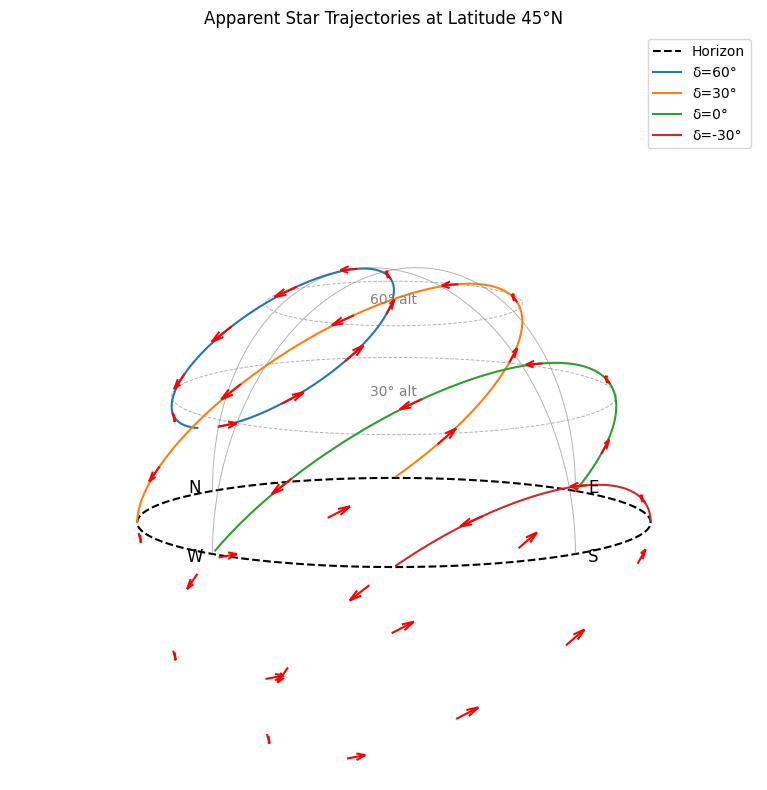

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Observer latitude (medium latitude)
latitude_deg = 45.0
lat = np.radians(latitude_deg)

# ---- Helper: Convert RA/Dec to alt-az Cartesian ----
def radec_to_altaz_cart(ra_hours, dec_deg, lst_hours, lat_rad):
    ha_deg = (lst_hours - ra_hours) * 15.0  # hour angle in degrees
    ha = np.radians(ha_deg)
    dec = np.radians(dec_deg)
    alt = np.arcsin(np.sin(lat_rad)*np.sin(dec) + np.cos(lat_rad)*np.cos(dec)*np.cos(ha))
    az = np.arctan2(-np.sin(ha), np.cos(lat_rad)*np.tan(dec) - np.sin(lat_rad)*np.cos(ha))
    # Cartesian conversion (z up)
    x = np.cos(alt) * np.sin(az)
    y = np.cos(alt) * np.cos(az)
    z = np.sin(alt)
    return x, y, z

# ---- Build Figure ----
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.set_proj_type('ortho')
ax.set_box_aspect([1,1,0.5])

# Horizon circle (z=0)
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), np.zeros_like(theta), 'k--', lw=1.5, label='Horizon')

# Cardinal direction labels (E,N,W,S)
labels = {'E':(1.1,0,0), 'N':(0,1.1,0), 'W':(-1.1,0,0), 'S':(0,-1.1,0)}
for txt,(x,y,z) in labels.items():
    ax.text(x, y, z, txt, ha='center', va='center', fontsize=12)

# Draw altitude circles (like 30°, 60° above horizon)
altitudes = np.radians([30, 60])
for alt in altitudes:
    r = np.cos(alt)
    z = np.sin(alt)
    ax.plot(r*np.cos(theta), r*np.sin(theta), np.full_like(theta,z), 
            '--', lw=0.7, color='gray', alpha=0.6)
    ax.text(0,0,z, f'{np.degrees(alt):.0f}° alt', color='gray', ha='center')

# Draw azimuth meridians (0°=N,90°=E,etc)
azimuths = np.radians([0,90,180,270])
for az in azimuths:
    alt = np.linspace(0, np.pi/2, 100)
    x = np.cos(alt)*np.sin(az)
    y = np.cos(alt)*np.cos(az)
    z = np.sin(alt)
    ax.plot(x, y, z, color='gray', lw=0.7, alpha=0.6)

# ---- Plot several star trajectories (constant Dec circles) ----
ras = np.linspace(12, -11, 200)
for dec_deg in [60, 30, 0, -30]:
    xs, ys, zs = [], [], []
    for ra in ras:
        x,y,z = radec_to_altaz_cart(ra, dec_deg, lst_hours=0, lat_rad=lat)
        xs.append(x); ys.append(y); zs.append(z)
    # keep only points above horizon
    xs, ys, zs = np.array(xs), np.array(ys), np.array(zs)
    above = zs >= 0
    ax.plot(xs[above], ys[above], zs[above], lw=1.5, label=f"δ={dec_deg}°")

    dx = np.gradient(xs)
    dy = np.gradient(ys)
    dz = np.gradient(zs)

    # Add arrows along the path
    skip = 20  # plot every 5 points to avoid clutter
    ax.quiver(xs[::skip], ys[::skip], zs[::skip], 
            dx[::skip], dy[::skip], dz[::skip], 
            length=0.1, normalize=True, color='red', arrow_length_ratio=0.5)

# ---- Labels & cosmetics ----
ax.set_title(f"Apparent Star Trajectories at Latitude {latitude_deg:.0f}°N")
ax.set_xlabel('East-West (x)')
ax.set_ylabel('North-South (y)')
ax.set_zlabel('Altitude (z)')
ax.legend()
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(0,1)
ax.set_axis_off()
ax.view_init(elev=10, azim=-135)
plt.tight_layout()
plt.show()


In [3]:
from HARey.curved_text import curved_text
from HARey.astro_functions import ecliptic2radec
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch, Circle
from matplotlib.transforms import Affine2D

from matplotlib.markers import MarkerStyle

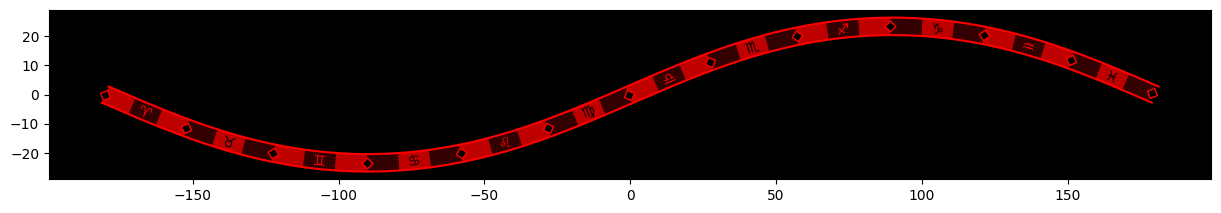

In [4]:
from matplotlib.markers import MarkerStyle


n_points = 361
length = 10
d = int(n_points/360*10)
ecl_x, ecl_y = ecliptic2radec(np.linspace(-180, 180, n_points+1), np.zeros(n_points+1))

dx = np.gradient(ecl_x)
dy = np.gradient(ecl_y)
l = np.sqrt(dx**2 + dy**2)
nx, ny = dy/l, -dx/l
w = 3
x1, x2 = ecl_x + w*nx, ecl_x - w*nx
y1, y2 = ecl_y + w*ny, ecl_y - w*ny

fig, ax = plt.subplots(1,1, figsize=(15,4))
ax.set_facecolor('k')
ax.plot(x1, y1, 'r')
ax.plot(x2, y2, 'r')

for i in range(int(360/10)):
    alpha = 0.75 if i%2==0 else 0.2
    patch_path = np.vstack([np.column_stack((x1[i*d:i*d+d+1], y1[i*d:i*d+d+1])), np.column_stack((x2[i*d:i*d+d+1][::-1], y2[i*d:i*d+d+1][::-1]))])
    patch = Polygon(patch_path, fc='r', alpha=alpha, ec='none')
    ax.add_patch(patch)

zodiac_symbols = ['\u2648', '\u2649', '\u264A', '\u264B', '\u264C', '\u264D','\u264E', '\u264F', '\u2650', '\u2651', '\u2652', '\u2653']

for i, (text, t) in enumerate(zip(zodiac_symbols, range(int(n_points/360*15), n_points, int(n_points/360*30)))):
    #circle = Circle((ecl_x[t], ecl_y[t]), radius=2, edgecolor='r', facecolor = 'w', fill=True)
    #ax.add_patch(circle)
    text_path = TextPath((0, 0), text, size=5)
    bb = text_path.get_extents()
    # Center the text path
    text_centered = Affine2D().translate(-0.5 * (bb.x0 + bb.x1), -0.5 * (bb.y0 + bb.y1)).transform_path(text_path)
    text_rotated = Affine2D().rotate(np.atan2(dy[t], dx[t])).transform_path(text_centered)
    text_translated = Affine2D().translate(ecl_x[t], ecl_y[t]).transform_path(text_rotated)
    color = 'r' if i%2==0 else 'k'
    patch = PathPatch(text_translated, color=color, linewidth=0)
    ax.add_patch(patch)

for i in range(0, n_points, int(n_points/360*30)):
    t = Affine2D().rotate(np.atan2(dy[i], dx[i]))
    ax.scatter(ecl_x[i], ecl_y[i], s=30, marker=MarkerStyle('D', transform=t), edgecolor='r', facecolor='k')

ax.set_aspect('equal')

In [5]:
con_names = [harey.names[id] for id in harey.con_ids]
sorted_IDs = [id for _, id in sorted( zip(con_names,harey.con_ids))]

NameError: name 'harey' is not defined

In [ ]:
from fontTools.ttLib import TTFont

font = TTFont("KsConstellationSymbolsFV.ttf")

# Get Unicode → glyph mapping
unicode_to_glyph = {}
for table in font["cmap"].tables:
    if table.platformID == 3 and table.platEncID in (1, 10):
        unicode_to_glyph.update(table.cmap)

# ID → Unicode codepoint
custom_glyph_ids = dict( zip(sorted_IDs, [chr(i) for i in range(33, 125)]))



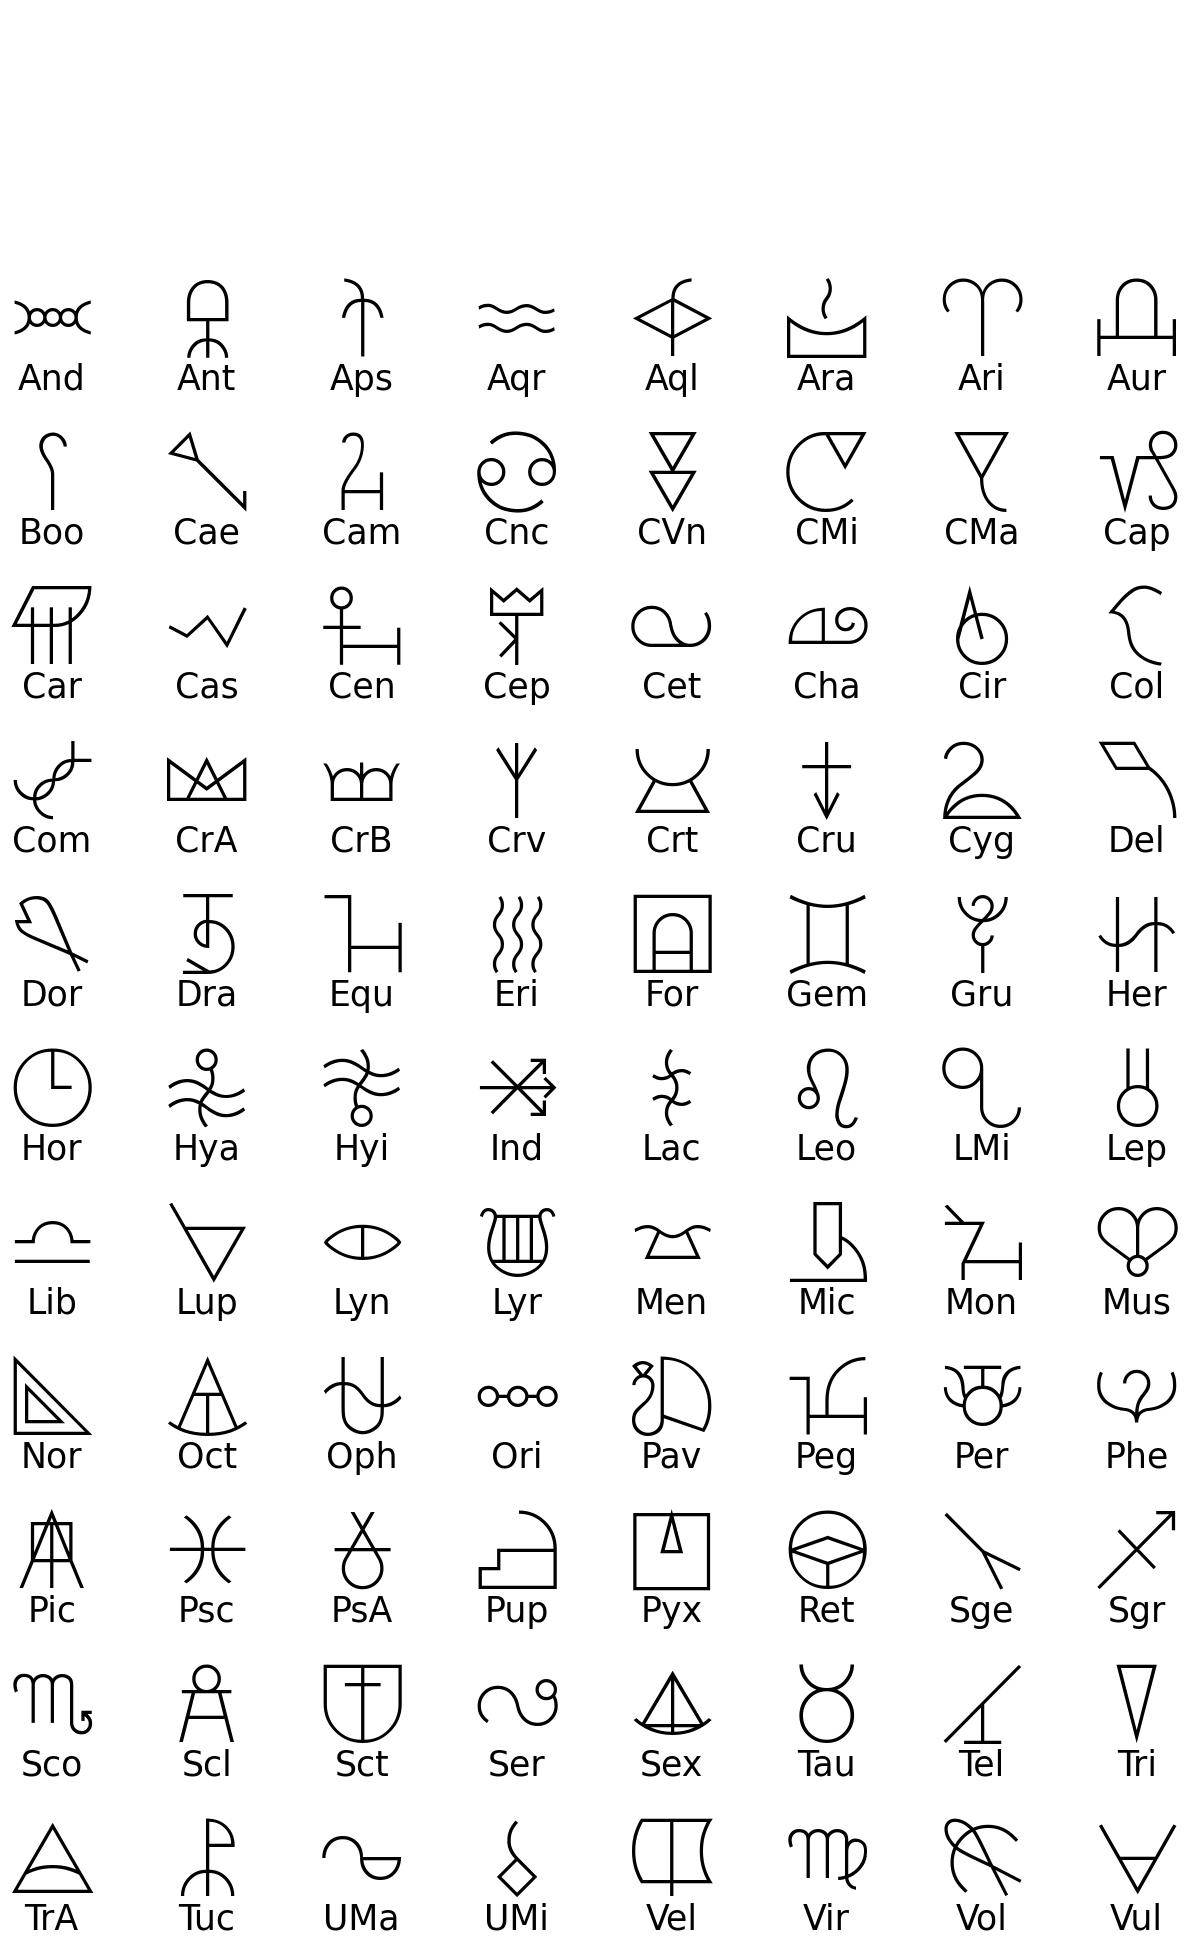

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

FONT_PATH = "KsConstellationSymbolsFV.ttf"

symbol_prop = fm.FontProperties(fname=FONT_PATH)
font_prop = fm.FontProperties(family='DejaVu Sans')
plt.figure(figsize=(4, 4))
for i, id in enumerate(sorted_IDs):
    j, k = i%8, i//8
    plt.text(0.5*j, - 0.5*k, custom_glyph_ids[id], fontproperties=symbol_prop, fontsize=60, ha="center", va="center")
    plt.text(0.5*j, - 0.5*k - 0.2, id, fontproperties=font_prop, fontsize=25, ha="center", va="center")
 
plt.axis("off")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

def rich_text(ax, x, y, segments, va="baseline"):
    """
    Draw text segments with different fonts aligned on the same baseline.

    segments: [(string, FontProperties), ...]
    """
    fig = ax.figure
    renderer = fig.canvas.get_renderer()

    current_x = x
    baseline_y = y

    for text, font in segments:
        t = ax.text(current_x, baseline_y, text,
                    fontproperties=font,
                    va=va, ha="left")

        fig.canvas.draw()

        bbox = t.get_window_extent(renderer=renderer)

        # advance x position
        current_x = ax.transData.inverted().transform((bbox.x1, bbox.y0))[0]

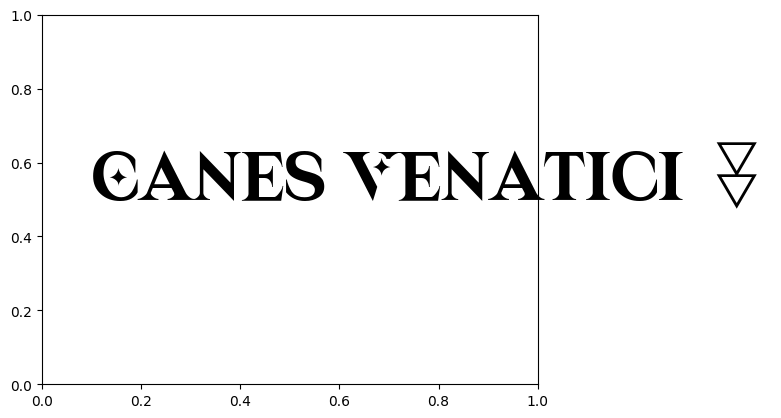

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

name_font = FontProperties(fname = 'fonts/TheWalkyr.ttf', size=50)
symbol_font = FontProperties(fname="KsConstellationSymbolsFV.ttf", size=50)

fig, ax = plt.subplots()

rich_text(
    ax, 0.1, 0.5,
    [
        ("Canes Venatici ", name_font),
        (custom_glyph_ids['CVn'], symbol_font)
    ]
)

ax.set_xlim(0,1)
ax.set_ylim(0,1)

plt.show()

In [6]:
from HARey.harey_main import HAReyMain

In [7]:
harey = HAReyMain(mw_file='HARey/mw_clean_10_deg.json')

Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!
Loading the milky way shape....       Done!


Using the tarot-round format, 2.75x4.75 in, using the template at /home/menegattig/Desktop/HARey_constellations_cards/HARey/cardbacks/tarot_round.png


(<Figure size 500x100 with 1 Axes>,)

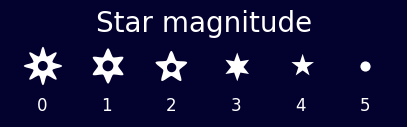

In [8]:
harey.set_limiting_magnitude(6.5, 0.05, 1.0)
harey.plot_legend(),

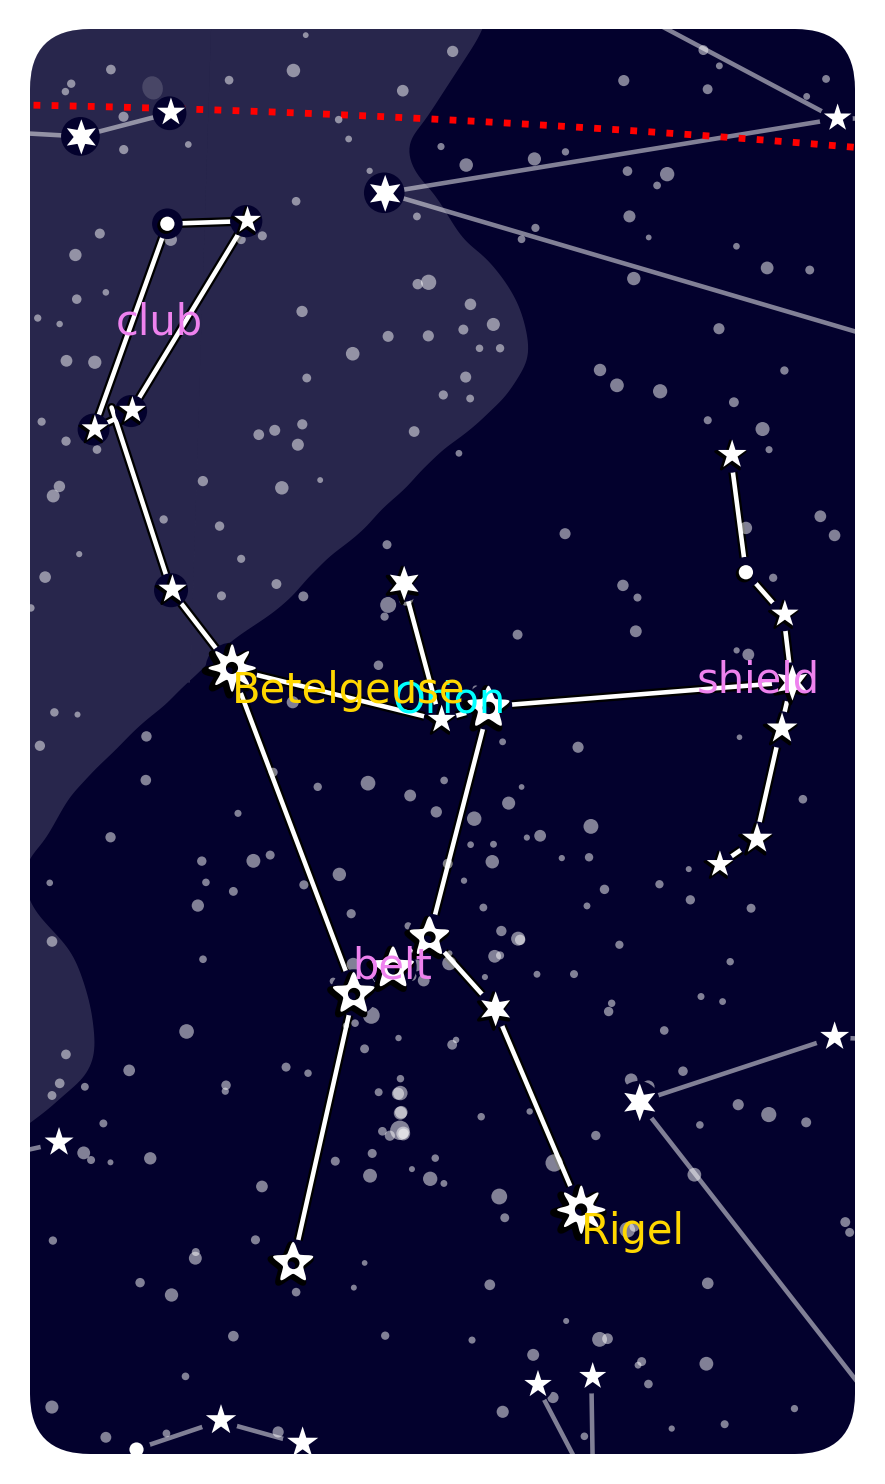

In [9]:
flags = ('con_names', 'con_lines', 'star_names', 'con_parts', 'milky_way')

harey.plot_card(*flags, id='Ori', BEST_AR=False)

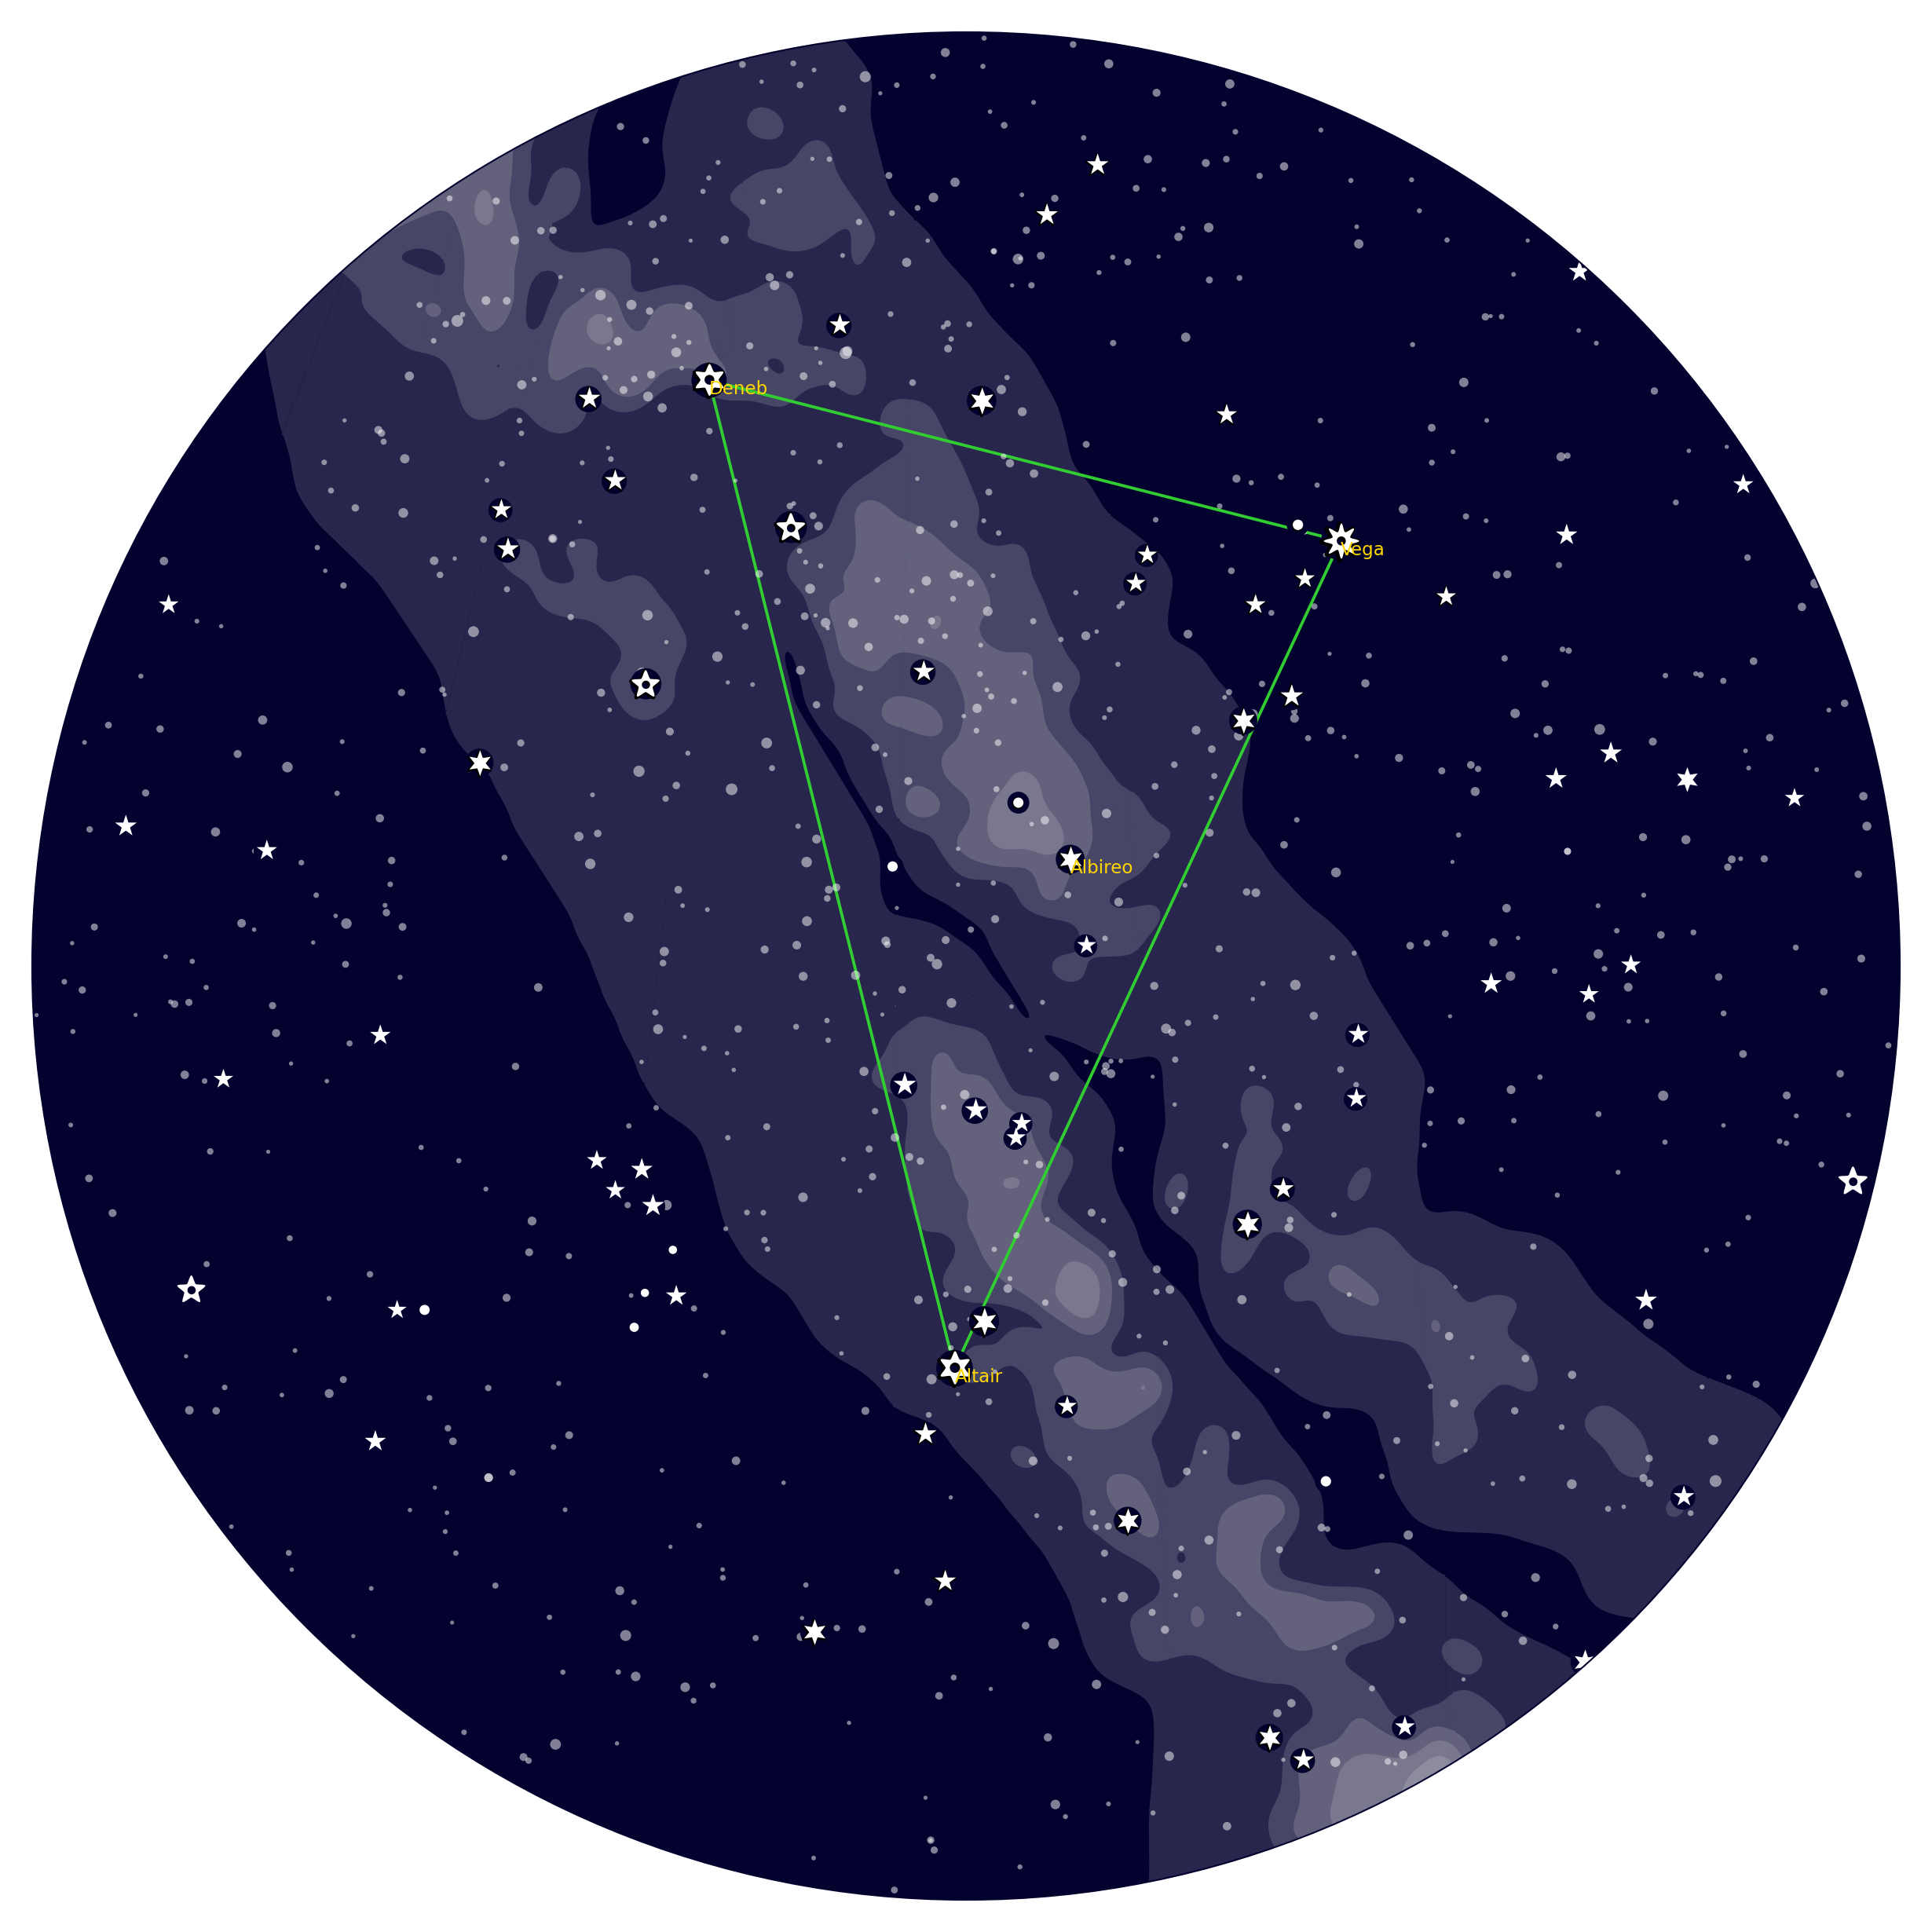

In [10]:
harey.plot_asterism('zodiac','milky_way', 'star_names',id='SumT')

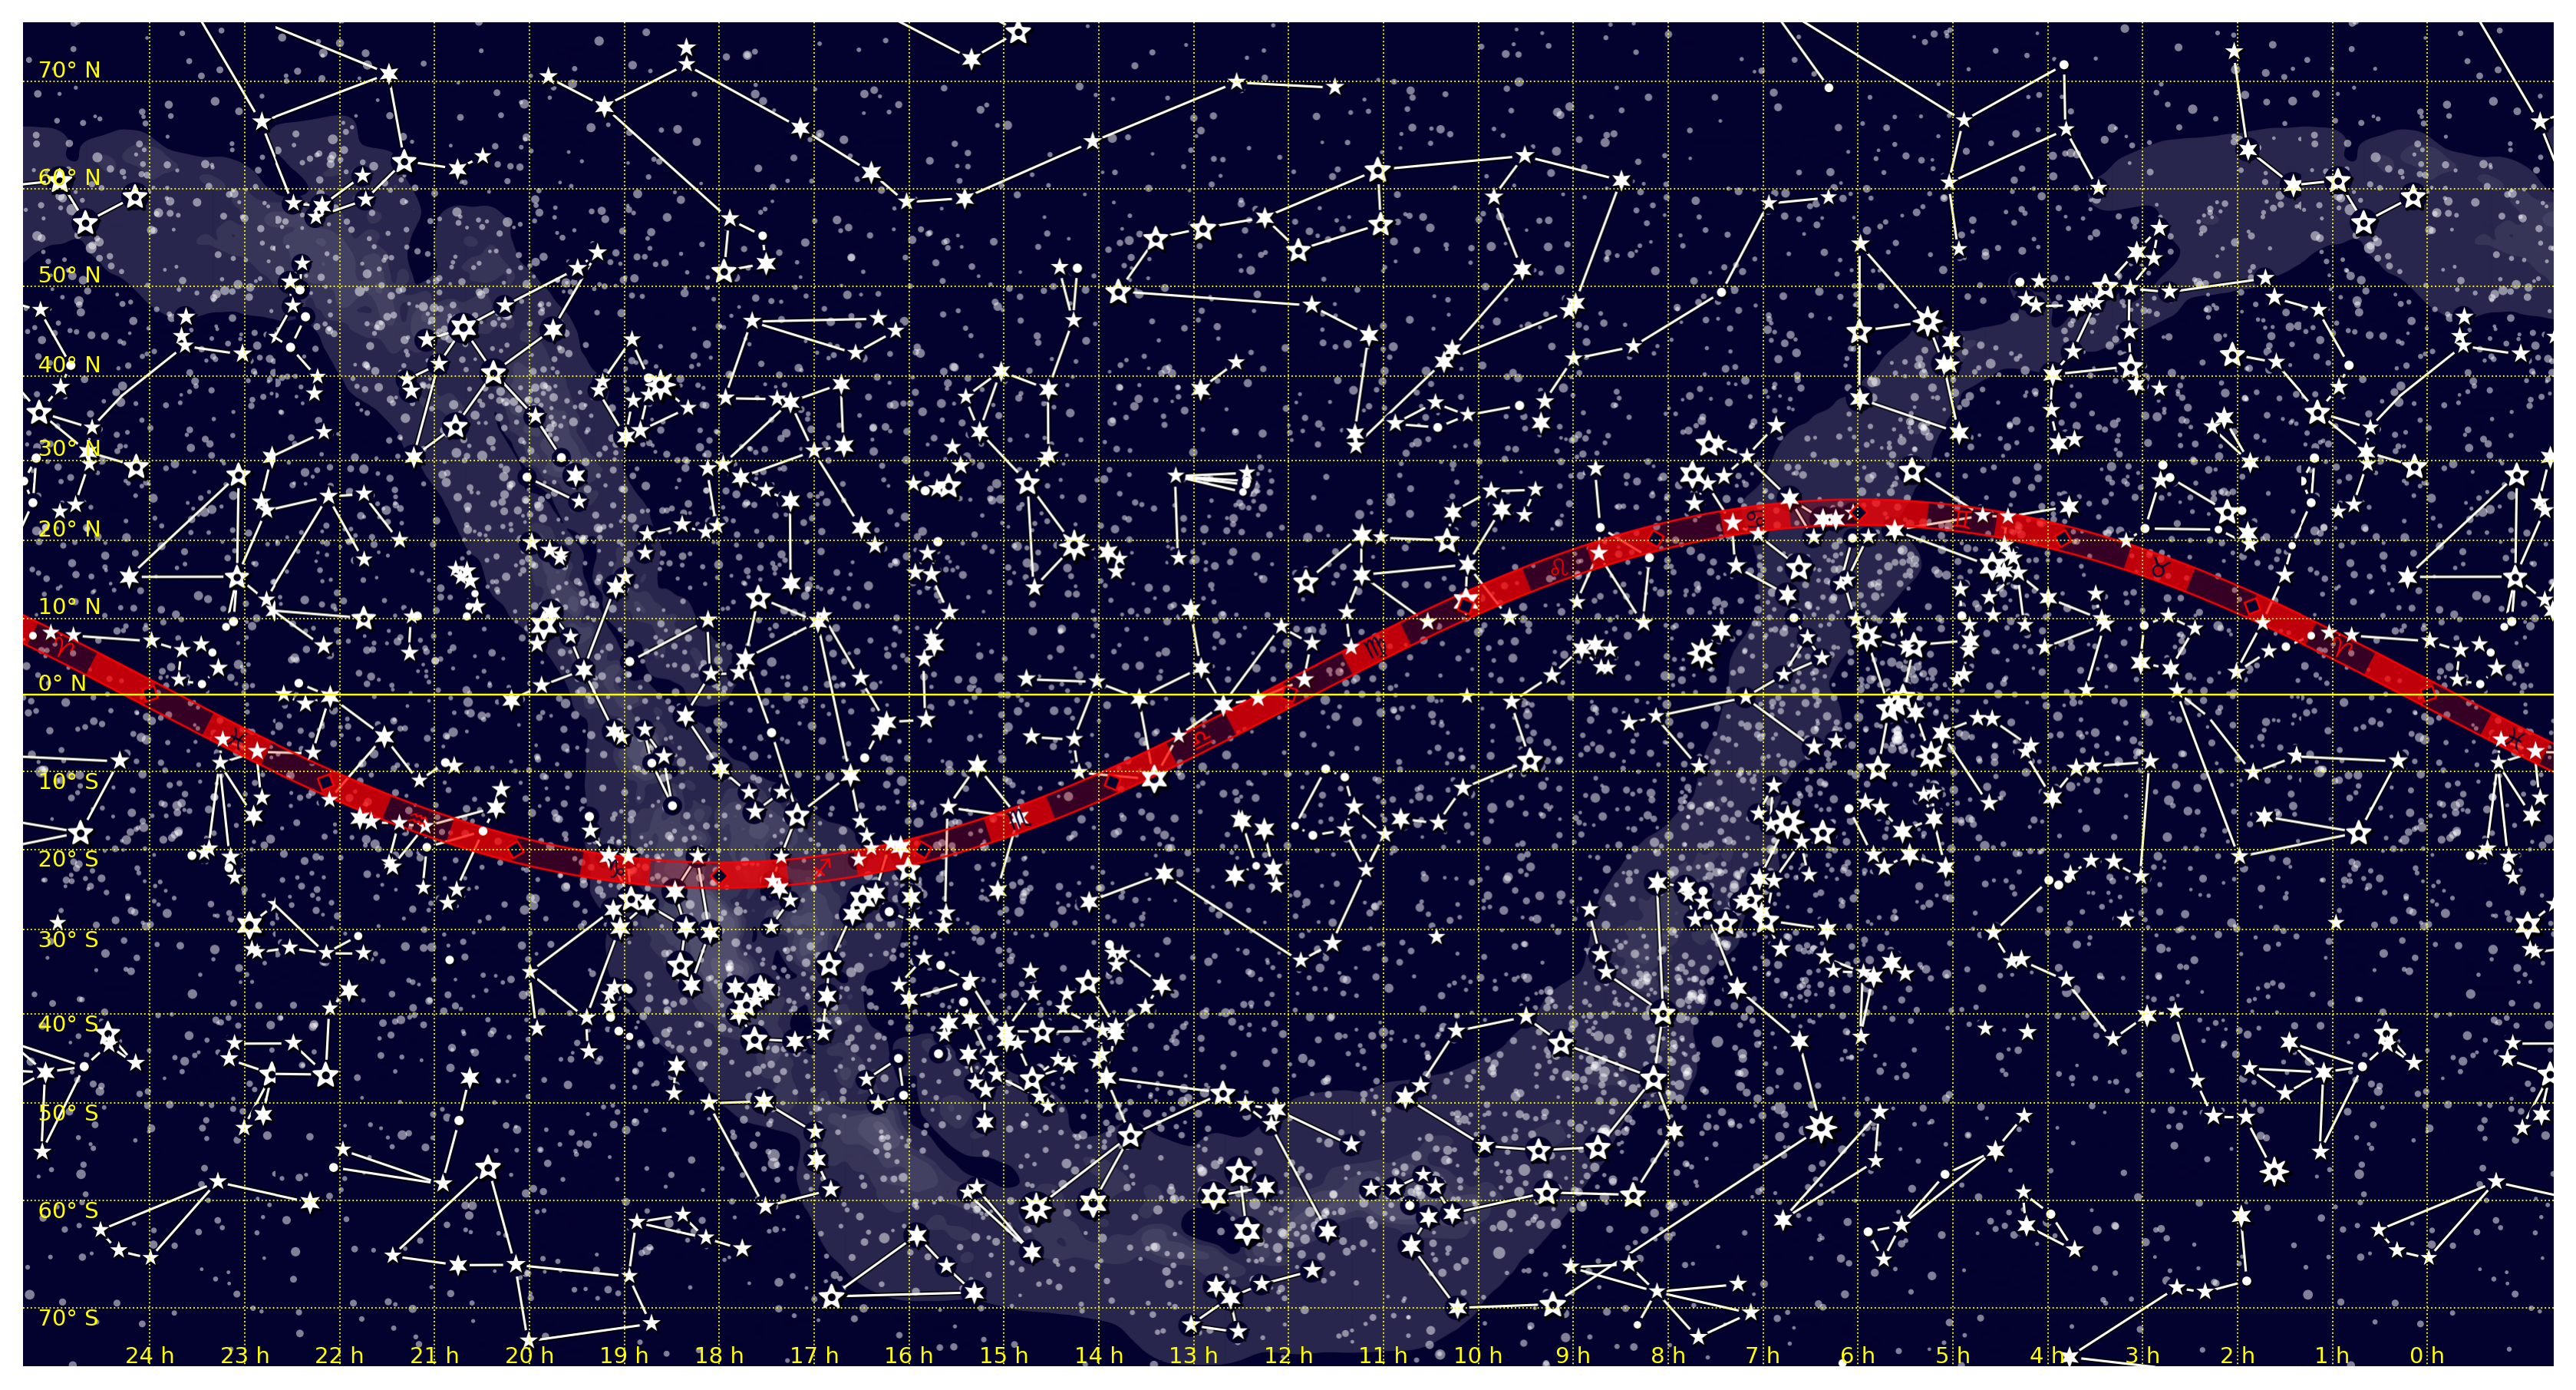

In [11]:
harey.set_milky_way_intensity(levels=5, min_intensity=0.15, max_intensity=0.35)
harey.equatorial_map('milky_way','con_lines', 'grid', 'zodiac', overlap=40, star_size=20)

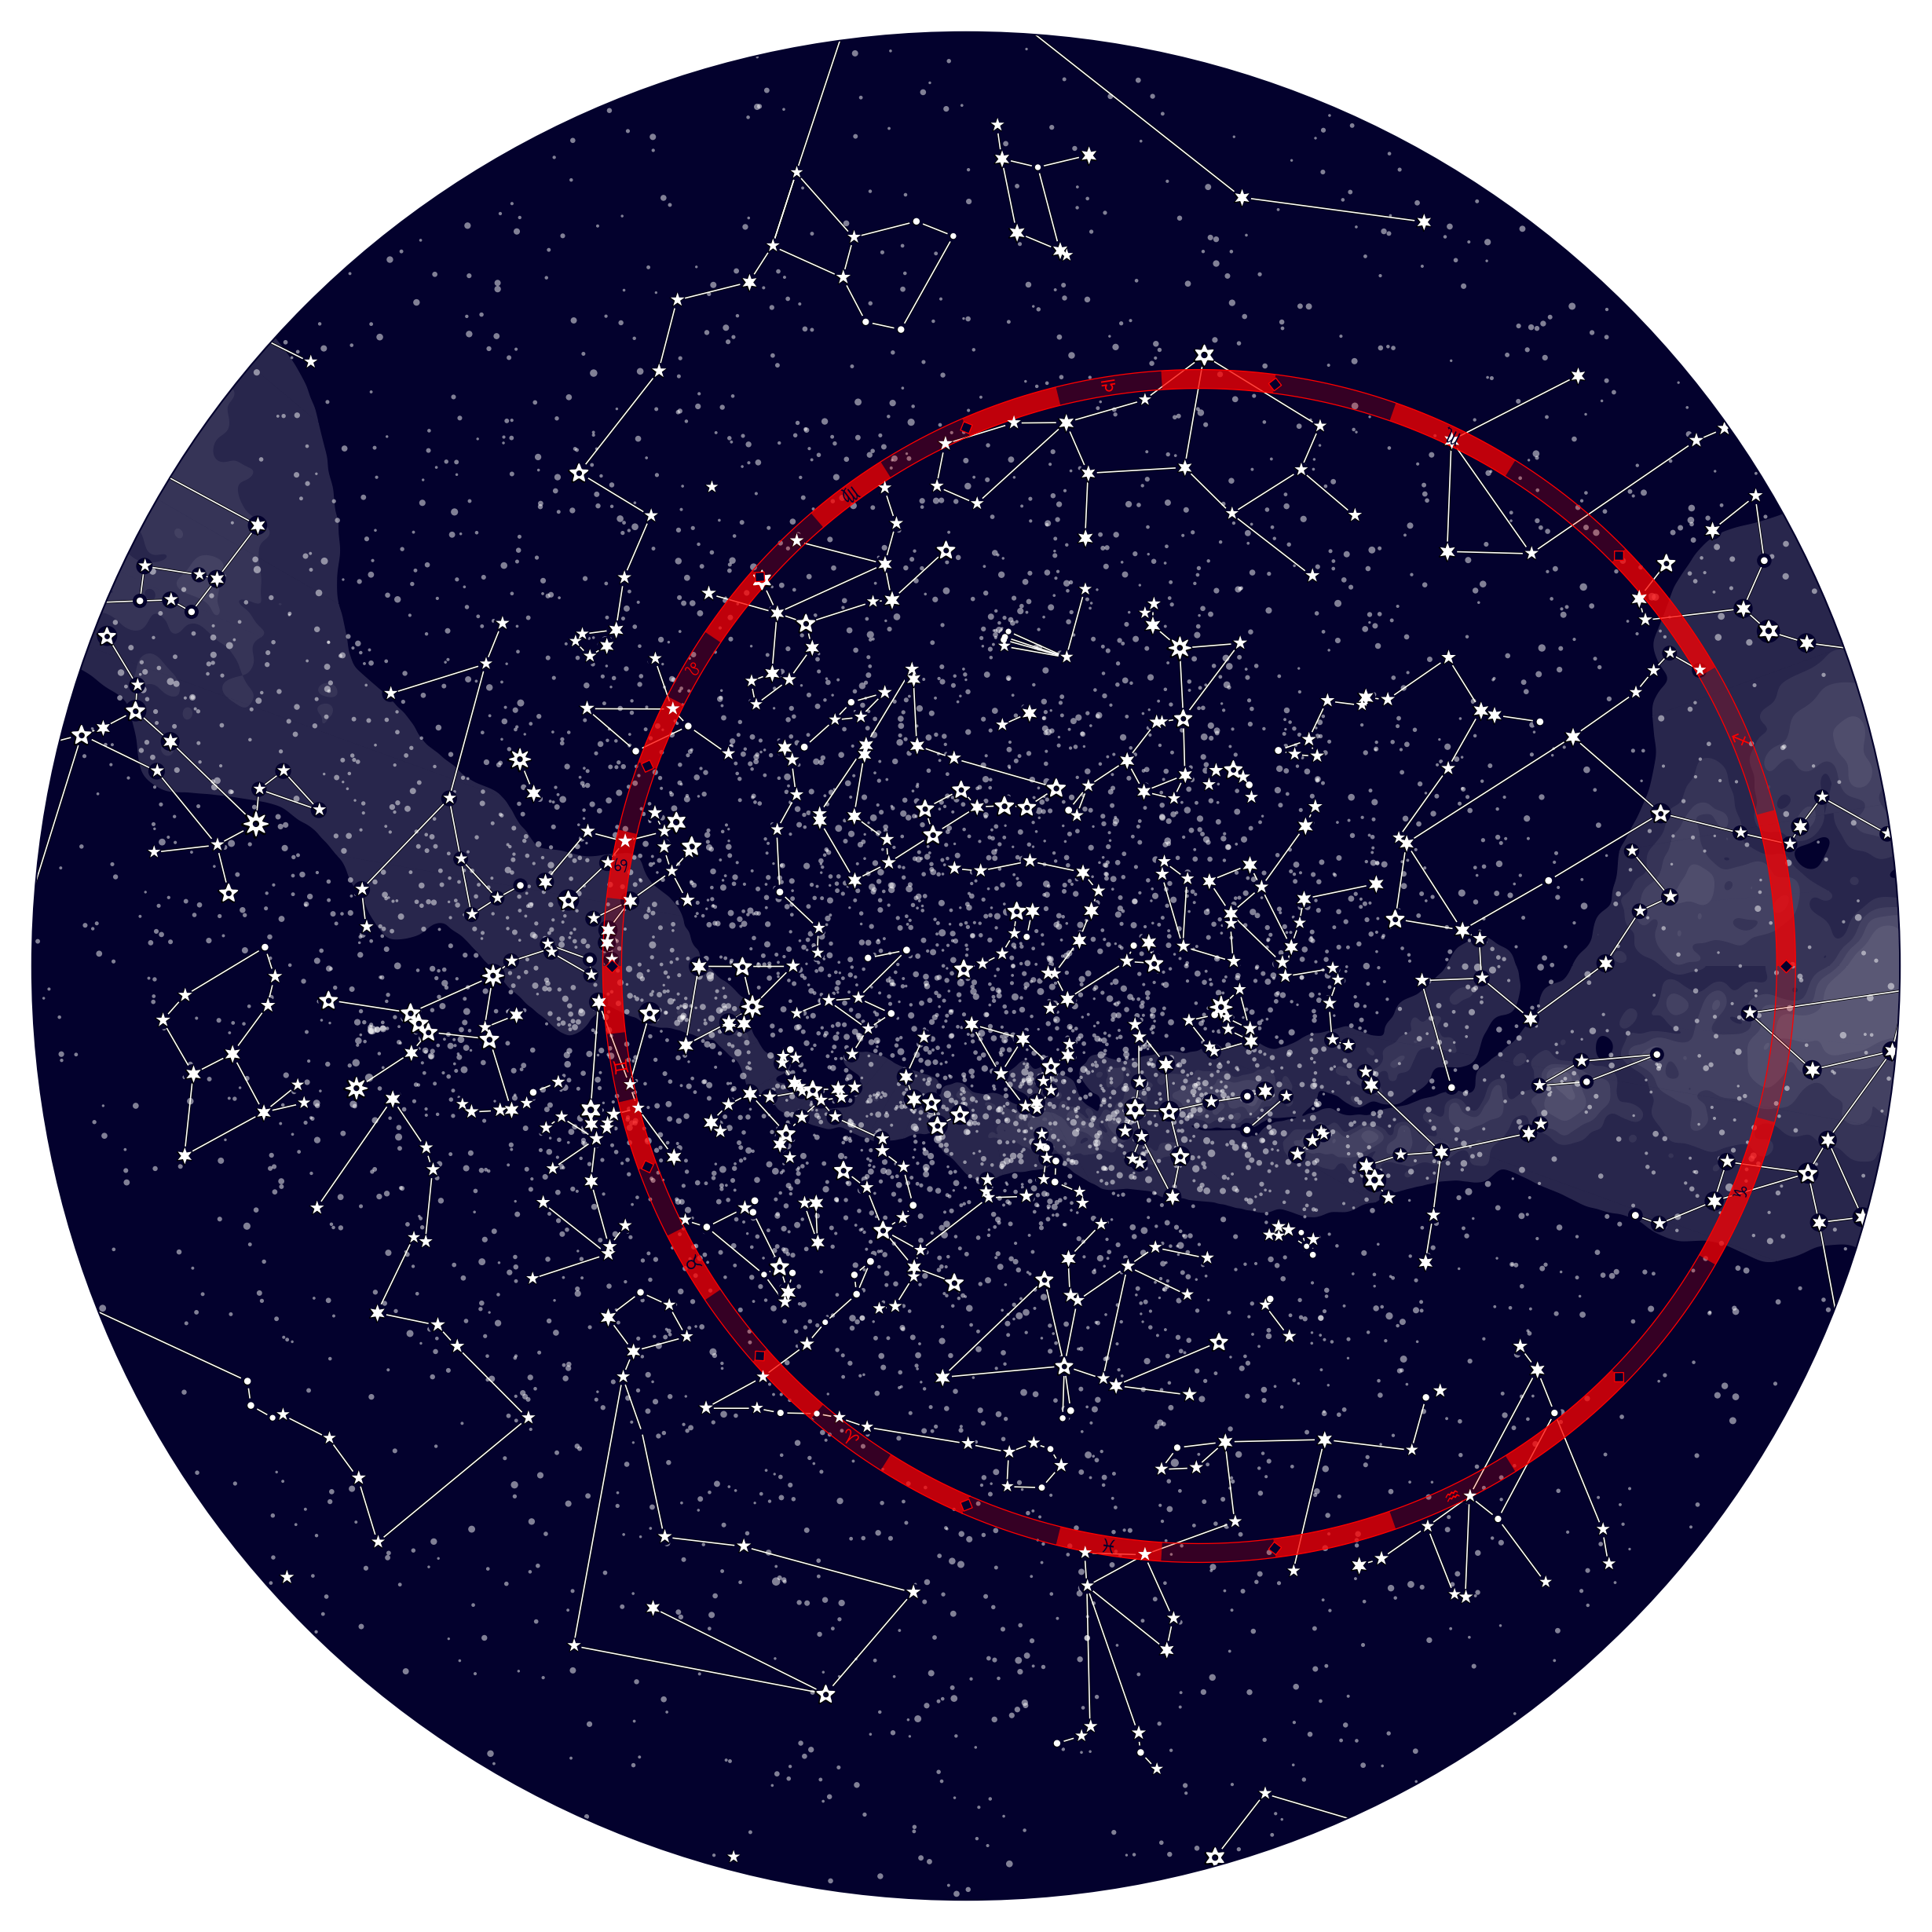

In [12]:
harey.polar_map('milky_way', 'zodiac', 'con_lines', FOV=240, mode='stereo')

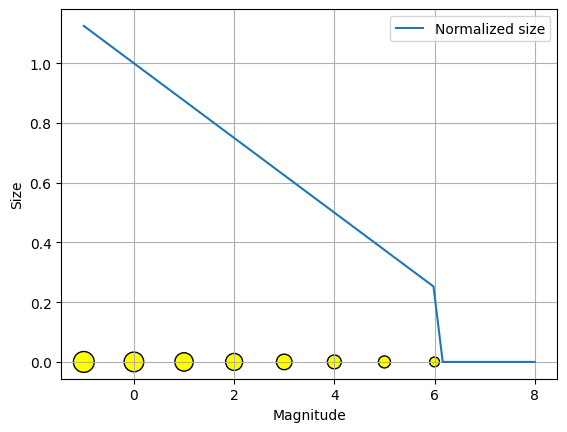

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def mag2size(
    mag, 
    limiting_mag=6, 
    limit_size=0.0, 
    power=1.0
):
    """
    Convert star magnitude to marker size for plotting, modeling apparent size of Airy disks.
    
    Parameters:
    - mag : float or array-like : star magnitude
    - limiting_mag : float : faintest magnitude visible (stars fainter → size 0)
    - limit_size : float : minimum size for faint stars (can be 0)
    - base_size : float : size of a mag=0 star
    - airy_radius : bool : if True, size scales roughly linearly with "Airy disk radius"
    - power : float or None : if not None, apply gentle power-law scaling (e.g., 0.3-0.5)
    
    Returns:
    - size : float or np.array : marker size for plt.scatter
    """
    import numpy as np
    
    mag = np.asarray(mag)
    size = np.zeros_like(mag, dtype=float)
    
    # Only stars brighter than limiting magnitude
    visible = mag <= limiting_mag
    m_vis = mag[visible]
    
    airy = (1 - m_vis / limiting_mag)
    airy = np.maximum(airy, 0)  # clip lower bound
    airy = airy**power

    size[visible] = airy*(1 - limit_size) + limit_size
    
    return size

mag = lambda x: mag2size(x, 6, 0.25, power = 1.0)

x = np.linspace(-1,8,50)
y =mag(x)



plt.plot(x, y, label="Normalized size")
stars = np.arange(-1,8,1)
plt.scatter(stars, np.zeros_like(stars), s=mag(stars)*200, color='yellow', edgecolor='black')
plt.grid()
plt.xlabel("Magnitude")
plt.ylabel("Size")
plt.legend()
plt.show()

In [14]:
def mag2size(mag, limiting_mag=6.0, limit_size=0.05, power=0.5):
    """
    Return a normalized star size for plotting.
    
    Parameters
    ----------
    mag : float or array-like
        Star magnitude.
    limiting_mag : float
        Magnitude limit; fainter stars are invisible.
    limit_size : float
        Size value for faintest visible star (mag = limiting_mag).
    power : float
        Power-law exponent (0.5 gives relaxed scaling).

    Returns
    -------
    size : float or ndarray
        Normalized size: 1 for mag=0, limit_size for mag=limiting_mag, 0 beyond.
    """
    import numpy as np

    mag = np.asarray(mag)
    size = np.zeros_like(mag, dtype=float)

    mask = mag <= limiting_mag
    if np.any(mask):
        x = mag[mask] / limiting_mag  # normalized magnitude 0..1
        size[mask] = limit_size + (1 - limit_size) * (1 - x**power)

    return size

In [15]:
mag2size(0)

array(1.)

In [16]:
mag2size(8)

array(0.)